# **Importing Libiraries**

In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pickle
import json
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [82]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix , roc_auc_score, roc_curve
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Digital Signal Processing

In [83]:
#Low pass Fillter
def butter_lowpass_filter(data, cutoff=20, fs=100, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    try:
        return filtfilt(b, a, data)
    except ValueError:
        return data

In [84]:
#DataFrame handling
def filter_dataframe(df, fs=100):
    for col in ['acc_x', 'acc_y', 'acc_z',
                'gyro_x', 'gyro_y', 'gyro_z']:
        if col in df.columns:
            df[col] = butter_lowpass_filter(df[col].fillna(0), cutoff=20, fs=fs)
    return df

In [85]:
    feature_cols = ['acc_x', 'acc_y', 'acc_z',
                    'gyro_x', 'gyro_y', 'gyro_z',
                    'delta_t']

In [86]:
def create_windows(df, window_size=40, overlap=20):
    # حساب Δt (بالثواني)
    df['delta_t'] = df['timestamp_ms'].diff().fillna(0)
    if df['delta_t'].max() > 100:  
        df['delta_t'] /= 1000.0

    # اختيار الأعمدة
    feature_cols = ['acc_x', 'acc_y', 'acc_z',
                    'gyro_x', 'gyro_y', 'gyro_z',
                    'delta_t']

    features = df[feature_cols].values
    labels = df['label'].values

    X, y = [], []
    step = window_size - overlap
    for start in range(0, len(df) - window_size + 1, step):
        end = start + window_size
        X.append(features[start:end])
        y.append(int(labels[end - 1]))
    return np.array(X), np.array(y)

In [87]:
feature_cols

['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'delta_t']

In [88]:
def clean_dataframe(df):

    # نحول الأعمدة الرقمية فقط
    numeric_cols = [
        'timestamp_ms',
        'acc_x','acc_y','acc_z',
        'gyro_x','gyro_y','gyro_z'
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # نمسح أي صف فيه NaN (غالبًا experiment in crash)
    df = df.dropna(subset=numeric_cols)

    return df.reset_index(drop=True)


In [89]:
#preparing Directory
def process_directory(base_dir):
    X_list, y_list = [], []
    for file in os.listdir(base_dir):
        if file.endswith('.csv'):
            path = os.path.join(base_dir, file)
            df = pd.read_csv(path)

            if len(df) < 10:
                continue  

            df = df.sort_values(by='timestamp_ms').reset_index(drop=True)
            df = filter_dataframe(df)

            X, y = create_windows(df)
            if len(X) > 0:
                X_list.append(X)
                y_list.append(y)

    if len(X_list) == 0:
        return np.empty((0, 10, 10)), np.empty((0,))
    return np.vstack(X_list), np.hstack(y_list)

In [90]:
#Loading and Preparing Data
train_path = r"/kaggle/input/datasets/mohamedkhalf/dataset-manual/train"
test_path  = r"/kaggle/input/datasets/mohamedkhalf/dataset-manual/test"

# ✅ تحميل ومعالجة البيانات
X_train, y_train = process_directory(train_path)
X_test, y_test   = process_directory(test_path)

In [91]:
#Scaling 
scaler = StandardScaler()
num_features = X_train.shape[2]

# Seperate Delat_t
X_train_signals = X_train[:, :, :-1]
X_test_signals  = X_test[:, :, :-1]

# scaling the signals
X_train_scaled = scaler.fit_transform(X_train_signals.reshape(-1, num_features - 1)).reshape(X_train_signals.shape)
X_test_scaled  = scaler.transform(X_test_signals.reshape(-1, num_features - 1)).reshape(X_test_signals.shape)

# Scale Delta_t between[0:1]
train_delta_t = X_train[:, :, -1]
test_delta_t  = X_test[:, :, -1]

max_dt = max(train_delta_t.max(), test_delta_t.max())
train_delta_t /= max_dt
test_delta_t  /= max_dt

#concatenating Delta_t with other data
X_train_final = np.concatenate([X_train_scaled, train_delta_t[..., np.newaxis]], axis=2)
X_test_final  = np.concatenate([X_test_scaled,  test_delta_t[..., np.newaxis]], axis=2)

In [92]:
feature_cols

['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'delta_t']

In [93]:
#saving the data
output_path = r"/kaggle/working/prepared_data"
np.savez(output_path,X_train=X_train_final, y_train=y_train,X_test=X_test_final, y_test=y_test)

print("Done")
print(f"Train shape: {X_train_final.shape}, Test shape: {X_test_final.shape}")

Done
Train shape: (862, 40, 7), Test shape: (240, 40, 7)


In [94]:
#loading Numpy
data = np.load(r"/kaggle/working/prepared_data.npz")
X_train3d, y_train = data['X_train'], data['y_train']
X_test3d, y_test   = data['X_test'],  data['y_test']

print("Shapes:", X_train3d.shape, y_train.shape, X_test3d.shape, y_test.shape)



Shapes: (862, 40, 7) (862,) (240, 40, 7) (240,)


# Modeling and Evaluation

In [95]:
X_train3d.shape , y_train.shape ,X_test3d.shape , y_test.shape

((862, 40, 7), (862,), (240, 40, 7), (240,))

In [96]:
10, num_features

(10, 7)

In [97]:
model = tf.keras.Sequential([
    layers.Conv1D(16, kernel_size=3, activation="relu", 
                  input_shape=(10, num_features)),
    layers.Conv1D(8, kernel_size=3, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 8, 16)          │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 6, 8)           │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 8)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 825 (3.22 KB)

 Trainable params: 825 (3.22 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
X_test.shape , y_test.shape , X_train.shape , y_train.shape

((240, 40, 7), (240,), (862, 40, 7), (862,))

In [100]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,                 
    restore_best_weights=True,
    verbose=1,
    min_delta=0.001              
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                 
    patience=5,                 
    min_lr=1e-7,                 
    verbose=1
)


checkpoint = ModelCheckpoint(
    'best_model.keras',          
    monitor='val_loss',
    save_best_only=True,         
    verbose=1
)

In [101]:
history = model.fit(
    X_train3d, y_train,
    validation_data=(X_test3d, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5074 - loss: 0.8062 - precision: 0.0807 - recall: 0.1419
Epoch 1: val_loss improved from inf to 0.55962, saving model to best_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.5138 - loss: 0.8032 - precision: 0.0856 - recall: 0.1461 - val_accuracy: 0.8958 - val_loss: 0.5596 - val_precision: 0.8302 - val_recall: 0.7333 - learning_rate: 0.0010
Epoch 2/200
21/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9045 - loss: 0.5121 - precision: 0.7353 - recall: 0.7768 
Epoch 2: val_loss improved from 0.55962 to 0.39044, saving model to best_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9047 - loss: 0.5016 - precision: 0.7416 - recall: 0.7616 - val_accuracy: 0.9042 - val_loss: 0.3904 - val_precision: 0.8776 - val_recall: 0.7167 - learning_rate: 0.0010
Epoch 3/200
21/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9390 - loss: 0.3441 - precision: 0.8651 - recall: 0.8102 
Epoch 3: val_loss impr

In [102]:
loss, acc, prec, rec= model.evaluate(X_test3d, y_test, verbose=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")

Accuracy : 0.9958
Precision: 1.0000
Recall   : 0.9833


In [103]:
y_prob = model.predict(X_test3d).ravel()

threshold = 0.8

y_pred = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
              precision    recall  f1-score   support

           0     0.9945    1.0000    0.9972       180
           1     1.0000    0.9833    0.9916        60

    accuracy                         0.9958       240
   macro avg     0.9972    0.9917    0.9944       240
weighted avg     0.9959    0.9958    0.9958       240

[[180   0]
 [  1  59]]


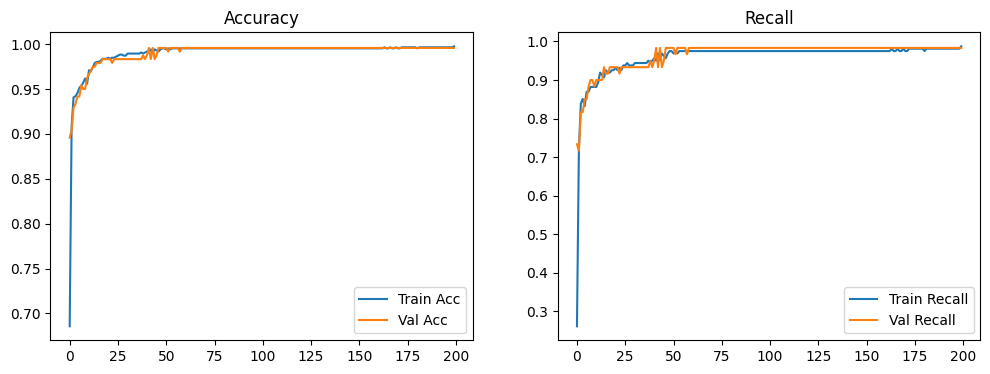

In [104]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.legend()
plt.title("Recall")

plt.show()


# **Preparing For ESP32**

In [109]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# حفظ المعاملات المهمة
params = {
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'max_delta_t': float(max_dt),
    'window_size': 40,
    'num_features': int(num_features),
    'cutoff_freq': 20,
    'sampling_rate': 100,
    'threshold': 0.99
}

with open('preprocessing_params.json', 'w') as f:
    json.dump(params, f, indent=2)

print("Scaler and parameters saved!")

Scaler and parameters saved!


In [110]:
from scipy.signal import butter

# حساب معاملات الفلتر
fs = 100
cutoff = 20
order = 4
nyq = 0.5 * fs
normal_cutoff = cutoff / nyq
b, a = butter(order, normal_cutoff, btype='low', analog=False)

# حفظ المعاملات
filter_params = {
    'b_coefficients': b.tolist(),
    'a_coefficients': a.tolist(),
    'order': order
}

with open('filter_params.json', 'w') as f:
    json.dump(filter_params, f, indent=2)

print("Filter coefficients saved!")
print("b:", b)
print("a:", a)

Filter coefficients saved!
b: [0.04658291 0.18633163 0.27949744 0.18633163 0.04658291]
a: [ 1.         -0.7820952   0.67997853 -0.1826757   0.03011888]


In [111]:
# إنشاء ملف header للـ ESP32
with open('preprocessing.h', 'w') as f:
    f.write('#ifndef PREPROCESSING_H\n')
    f.write('#define PREPROCESSING_H\n\n')
    
    # عدد الـ features
    f.write(f'const int NUM_FEATURES = {num_features};\n')
    f.write(f'const int WINDOW_SIZE = {params["window_size"]};\n')
    f.write(f'const float THRESHOLD = {params["threshold"]}f;\n\n')
    
    # Scaler mean
    f.write('const float SCALER_MEAN[] = {\n  ')
    f.write(',\n  '.join([f'{x:.6f}f' for x in scaler.mean_]))
    f.write('\n};\n\n')
    
    # Scaler scale
    f.write('const float SCALER_SCALE[] = {\n  ')
    f.write(',\n  '.join([f'{x:.6f}f' for x in scaler.scale_]))
    f.write('\n};\n\n')
    
    # Max delta_t
    f.write(f'const float MAX_DELTA_T = {max_dt:.6f}f;\n\n')
    
    # Filter coefficients (b)
    f.write('const float FILTER_B[] = {\n  ')
    f.write(',\n  '.join([f'{x:.10f}f' for x in b]))
    f.write('\n};\n\n')
    
    # Filter coefficients (a)
    f.write('const float FILTER_A[] = {\n  ')
    f.write(',\n  '.join([f'{x:.10f}f' for x in a]))
    f.write('\n};\n\n')
    
    f.write(f'const int FILTER_ORDER = {order};\n\n')
    f.write('#endif\n')

print("preprocessing.h created!")

preprocessing.h created!


In [112]:
# ============================================
# تحويل لـ float32 للـ ESP32 (بدون quantization)
# ============================================
import tensorflow as tf

print("=" * 50)
print("Converting model to float32 for ESP32")
print("=" * 50)

# 1. حفظ Keras model
model.save('best_model.keras')
print("✅ Keras model saved")

# 2. تحويل لـ float32 (بدون optimizations)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# لا تضيف أي optimizations للحصول على float32 نقي
tflite_model = converter.convert()

# حفظ الملف
with open('model_float32.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ Float32 model: {len(tflite_model)} bytes ({len(tflite_model)/1024:.2f} KB)")

# 3. تحويل لـ C header للـ ESP32
with open('model.h', 'w') as f:
    f.write('// FLOAT32 model for ESP32 IMU sensors\n')
    f.write(f'// Model size: {len(tflite_model)} bytes ({len(tflite_model)/1024:.2f} KB)\n')
    f.write('// No quantization - Full precision for sensor data\n\n')
    
    f.write('#ifndef MODEL_H\n')
    f.write('#define MODEL_H\n\n')
    f.write('alignas(8) const unsigned char model_data[] = {\n')
    
    for i in range(0, len(tflite_model), 12):
        f.write('  ')
        chunk = tflite_model[i:i+12]
        f.write(', '.join([f'0x{byte:02x}' for byte in chunk]))
        if i + 12 < len(tflite_model):
            f.write(',')
        f.write('\n')
    
    f.write('};\n\n')
    f.write(f'const unsigned int model_data_len = {len(tflite_model)};\n\n')
    f.write('#endif\n')

print("✅ model.h created for ESP32")
print("\nFiles created:")
print("  ✓ best_model.keras")
print("  ✓ model_float32.tflite")
print("  ✓ model.h ← Use this for ESP32 (float32, no quantization)")

Converting model to float32 for ESP32
✅ Keras model saved
Saved artifact at '/tmp/tmp5efxth9y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 7), dtype=tf.float32, name='keras_tensor_18')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139050025758032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139050025752272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139050512840464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139050025751888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139050025759376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139050025762640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139050025758416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139050025758800: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Float32 model: 7384 bytes (7.21 KB)
✅ model.h created for ESP32

Files created:
  ✓ best_model.kera

W0000 00:00:1775414041.823931      38 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775414041.823962      38 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
